# Exposure Data Mapping and Analysis

This notebook contains visualizations and summaries of exposure data, aggregated by county.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: enable nicer plots
sns.set(style="whitegrid")

# Load exposure GeoDataFrame
file_name = "TC_FL_HIIIMMN_H08_capra.csv"
#file_name = "FL_ian_reask_capra.csv"
res_path = os.path.join("..", "data", "results", file_name)
res_df_H08 = pd.read_csv(res_path)

# Preview the data
res_df_H08.head()

,id,PlanArea,NumberOfStories,MedianYearBuilt,ReplacementCost,StructureType,NumberOfUnits,CensusBlock,CensusTract,FootprintID,...,DS_2018280N18273,LossRatio_2022266N12294,RepairCost_2022266N12294,DS_2022266N12294,LossRatio_2022311N21293,RepairCost_2022311N21293,DS_2022311N21293,LossRatio_2023239N21274,RepairCost_2023239N21274,DS_2023239N21274
0,0,1853.000000,1.0,1976.0,251025.910,S3,1.0,121150026011001,12115002601,0,...,DS0: None,0.0,0.0,DS0: None,0.0,0.0,DS0: None,0.0,0.0,DS0: None
1,1,2242.000000,1.0,1976.0,394278.187,URM,1.0,121150026011014,12115002601,27,...,DS0: None,0.0,0.0,DS0: None,0.0,0.0,DS0: None,0.0,0.0,DS0: None
2,2,1472.000000,1.0,1976.0,371949.433,URM,2.0,121150026011014,12115002601,28,...,DS0: None,0.0,0.0,DS0: None,0.0,0.0,DS0: None,0.0,0.0,DS0: None
3,3,1125.000000,2.0,1976.0,1322329.916,URM,2.0,121150026011014,12115002601,29,...,DS0: None,0.0,0.0,DS0: None,0.0,0.0,DS0: None,0.0,0.0,DS0: None
4,4,1272.666667,3.0,1976.0,741018.109,URM,2.0,121150026011014,12115002601,30,...,DS0: None,0.0,0.0,DS0: None,0.0,0.0,DS0: None,0.0,0.0,DS0: None


In [2]:
# Load exposure GeoDataFrame
file_name = "TC_FL_HIIIMMN_ER11_capra.csv"
res_path = os.path.join("..", "data", "results", file_name)
res_df_ER11 = pd.read_csv(res_path)

In [3]:
# Load exposure GeoDataFrame
file_name = "FL_ian_reask_capra.csv"
res_path = os.path.join("..", "data", "results", file_name)
res_df_reask = pd.read_csv(res_path)



In [4]:
import pandas as pd

# Step 1: Filter columns starting with 'DS_'
ds_columns = [col for col in res_df_ER11.columns if col.startswith("DS_")]

# Step 2: Initialize summary dictionary
ds_summary = {}

# Step 3: Loop over DS columns and count each category
for col in ds_columns:
    event_id = col.split("_", 1)[1]  # extract event_id from column name
    counts = res_df_ER11[col].value_counts(dropna=False)
    ds_summary[event_id] = counts

# Step 4: Create a DataFrame from the summary
ds_counts_df = pd.DataFrame(ds_summary).fillna(0).astype(int).T  # transpose so events are rows

# Optional: sort DS columns in natural order if needed
sorted_columns = sorted(ds_counts_df.columns, key=lambda x: (x != 'DS0: None', x))
ds_counts_df = ds_counts_df[sorted_columns]

ds_counts_df


,DS0: None,DS1: Slight,DS2: Moderate,DS3: Extensive,DS4: Complete
2016242N24279,6632965,2960,1614,6066,2341
2016273N13300,6569286,7170,11564,30203,27723
2017242N16333,6405822,31631,42646,137284,28563
2018280N18273,6524446,26095,23455,35688,36262
2022266N12294,6009778,54185,80995,408196,92792
2022311N21293,6284411,37409,55204,268922,0
2023239N21274,6612497,5587,3954,9055,14853


In [5]:
import re

def compute_ds_counts(df, label):
    ds_columns = [col for col in df.columns if col.startswith("DS_")]
    ds_summary = {}
    for col in ds_columns:
        event_id = col.split("_", 1)[1]
        counts = df[col].value_counts(dropna=False)
        # Add label prefix to differentiate datasets
        counts.index = [f"{ds}_{label}" for ds in counts.index]
        ds_summary[event_id] = counts
    return pd.DataFrame(ds_summary).fillna(0).astype(int).T

def ds_sort_key(col):
    # Extract DS level (e.g., "DS1") while handling "DS0: None" consistently
    match = re.match(r"(DS\d+)", col)
    ds_level = match.group(1) if match else col
    suffix = col.split("_")[-1]
    return (int(ds_level[2:]) if ds_level.startswith("DS") else 999, suffix)

# Compute DS counts separately
ds_counts_1 = compute_ds_counts(res_df_H08, "H08")
ds_counts_2 = compute_ds_counts(res_df_ER11, "ER11")

# Merge side-by-side on event_id index
ds_comparison = ds_counts_1.join(ds_counts_2, how="outer").fillna(0).astype(int)

# Re-sort columns by DS level, then by dataset label (df1, df2)
sorted_cols = sorted(ds_comparison.columns, key=ds_sort_key)
ds_comparison = ds_comparison[sorted_cols]

# Optional: sort columns naturally
#sorted_cols = sorted(ds_comparison.columns, key=lambda x: (x.split("_")[1], x.split("_")[0]))
#ds_comparison = ds_comparison[sorted_cols]

ds_comparison


,DS0: None_ER11,DS0: None_H08,DS1: Slight_ER11,DS1: Slight_H08,DS2: Moderate_ER11,DS2: Moderate_H08,DS3: Extensive_ER11,DS3: Extensive_H08,DS4: Complete_ER11,DS4: Complete_H08
2016242N24279,6632965,6645033,2960,913,1614,0,6066,0,2341,0
2016273N13300,6569286,6585809,7170,8649,11564,5921,30203,45567,27723,0
2017242N16333,6405822,6309178,31631,50878,42646,44043,137284,156363,28563,85484
2018280N18273,6524446,6596893,26095,7976,23455,6094,35688,11197,36262,23786
2022266N12294,6009778,6536167,54185,10958,80995,11440,408196,29331,92792,58050
2022311N21293,6284411,6645946,37409,0,55204,0,268922,0,0,0
2023239N21274,6612497,6627205,5587,1810,3954,2423,9055,8395,14853,6113


## County-Level Aggregation
Aggregate exposure variables (e.g., `ReplacementCost`) by county.

In [6]:
# Aggregate by county
county_agg = res_df_ER11.groupby("County")[["ReplacementCost"]].sum().sort_values("ReplacementCost", ascending=False)
county_agg.head()

,ReplacementCost
County,
Miami-Dade,3.947657e+11
Broward,3.265320e+11
Palm Beach,2.834344e+11
Orange,2.740543e+11
Hillsborough,2.565539e+11


## Plot: Exposure variables by county

In [7]:
import geopandas as gpd

# STEP 1: Load Florida County Shapefile
# Replace the path with the actual location of your downloaded shapefile (must include .shp, .shx, .dbf)
county_fp = os.path.join("..", "data", "exposure", "tl_2024_us_county")
counties = gpd.read_file(county_fp)

# Preview column names to find the county name field
print(counties.columns)


Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='object')


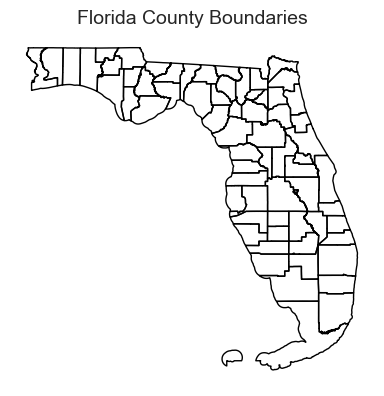

In [8]:
# Common fields include 'STATEFP' or 'STATE_NAME'
# Florida's FIPS code is '12'
florida_counties = counties[counties["STATEFP"] == '12']

# Plot only Florida
fig, ax = plt.subplots(figsize=(4, 5))
florida_counties.boundary.plot(ax=ax, linewidth=1, edgecolor="black")
ax.set_title("Florida County Boundaries", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

In [9]:
county_renames = {
    "ST LUCIE": "ST. LUCIE",
    "ST JOHNS": "ST. JOHNS"
}

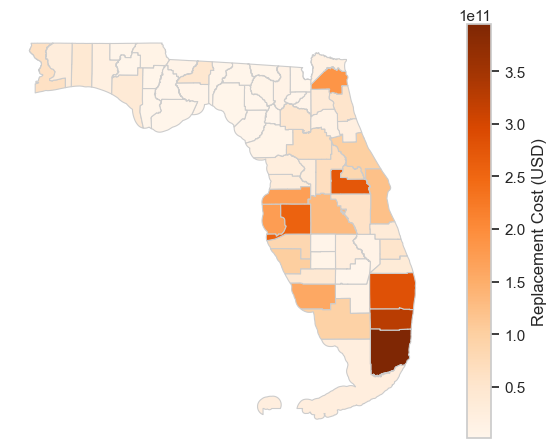

In [10]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# STEP 1: Filter counties for Florida only (assuming STATEFP = '12')
florida_counties = counties[counties["STATEFP"] == '12'].copy()

# STEP 2: Aggregate exposure data by county
agg_exposure = res_df_ER11.groupby("County")[["ReplacementCost"]].sum().reset_index()

# Clean up names for merge
agg_exposure["County"] = agg_exposure["County"].str.upper()
florida_counties["NAME"] = florida_counties["NAME"].str.upper()

agg_exposure["County"] = agg_exposure["County"].replace(county_renames)

# STEP 3: Merge exposure data into county geometries
merged = florida_counties.merge(agg_exposure, left_on="NAME", right_on="County", how="left")

# STEP 4: Plot choropleth map
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Create a divider for the axis
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)  # Shrink + pad colorbar

# Plot with custom colorbar axis
merged.plot(
    column="ReplacementCost",
    cmap="Oranges",
    linewidth=0.8,
    edgecolor="0.8",
    legend=True,
    ax=ax,
    cax=cax,  # Use custom colorbar axis
    legend_kwds={'label': 'Replacement Cost (USD)'},
    missing_kwds={
        "color": "lightgrey",
        "label": "No data",
        "edgecolor": "white"
    }
)

ax.axis("off")
plt.tight_layout()
plt.show()

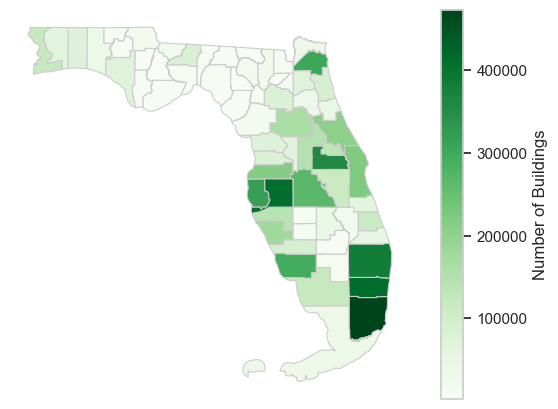

In [11]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# STEP 1: Filter counties for Florida only (assuming STATEFP = '12')
florida_counties = counties[counties["STATEFP"] == '12'].copy()

# STEP 2: Aggregate exposure data by county
agg_exposure = res_df_ER11.groupby("County")[["value"]].sum().reset_index()

# Clean up names for merge
agg_exposure["County"] = agg_exposure["County"].str.upper()
florida_counties["NAME"] = florida_counties["NAME"].str.upper()

agg_exposure["County"] = agg_exposure["County"].replace(county_renames)

# STEP 3: Merge exposure data into county geometries
merged = florida_counties.merge(agg_exposure, left_on="NAME", right_on="County", how="left")

# STEP 4: Plot choropleth map
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Create a divider for the axis
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)  # Shrink + pad colorbar

# Plot with custom colorbar axis
merged.plot(
    column="value",
    cmap="Greens",
    linewidth=0.8,
    edgecolor="0.8",
    legend=True,
    ax=ax,
    cax=cax,  # Use custom colorbar axis
    legend_kwds={'label': 'Number of Buildings'},
    missing_kwds={
        "color": "lightgrey",
        "label": "No data",
        "edgecolor": "white"
    }
)

ax.axis("off")
plt.tight_layout()
plt.show()

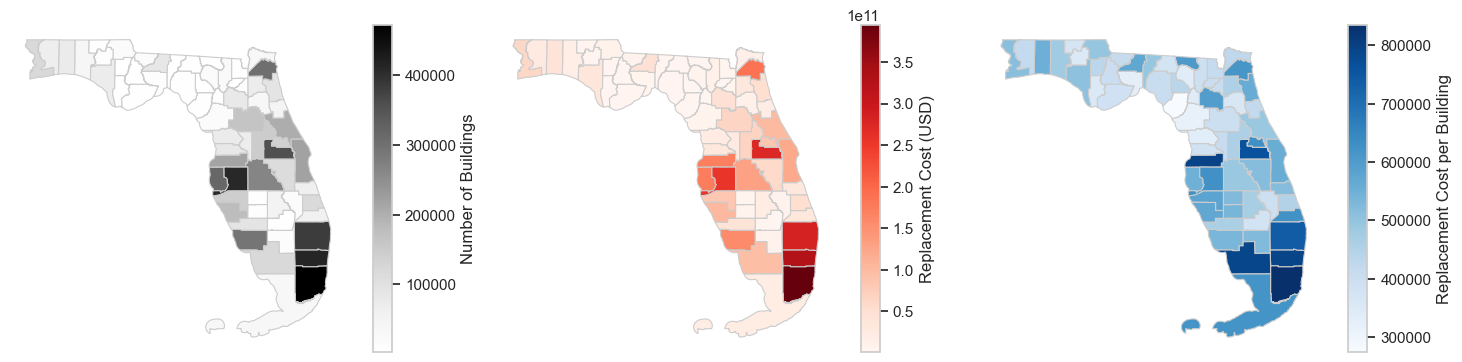

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# STEP 1: Filter counties for Florida
florida_counties = counties[counties["STATEFP"] == '12'].copy()
florida_counties["NAME"] = florida_counties["NAME"].str.upper()

# STEP 2: Aggregate metrics
agg_replacement = res_df_ER11.groupby("County")[["ReplacementCost"]].sum().reset_index()
agg_count = res_df_ER11.groupby("County").size().reset_index(name="BuildingCount")

# Clean names
agg_replacement["County"] = agg_replacement["County"].str.upper()
agg_count["County"] = agg_count["County"].str.upper()

# STEP 3: Merge metrics
agg_all = agg_replacement.merge(agg_count, on="County", how="outer")
agg_all["CostPerBuilding"] = agg_all["ReplacementCost"] / agg_all["BuildingCount"]

county_renames = {
    "ST LUCIE": "ST. LUCIE",
    "ST JOHNS": "ST. JOHNS"
}
agg_all["County"] = agg_all["County"].replace(county_renames)

# Merge with spatial geometries
merged_all = florida_counties.merge(agg_all, left_on="NAME", right_on="County", how="left")

# STEP 4: Create 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [
    ("BuildingCount", "Greys", "Number of Buildings"),
    ("ReplacementCost", "Reds", "Replacement Cost (USD)"),
    ("CostPerBuilding", "Blues", "Replacement Cost per Building")
]

for ax, (column, cmap, label) in zip(axes, metrics):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    merged_all.plot(
        column=column,
        cmap=cmap,
        linewidth=0.8,
        edgecolor="0.8",
        legend=True,
        ax=ax,
        cax=cax,
        legend_kwds={'label': label},
        missing_kwds={
            "color": "lightgrey",
            "label": "No data",
            "edgecolor": "white"
        }
    )
    ax.axis("off")

plt.tight_layout()
plt.savefig("../plots/fl_exposure_overview.png", dpi=300, bbox_inches="tight")
plt.show()


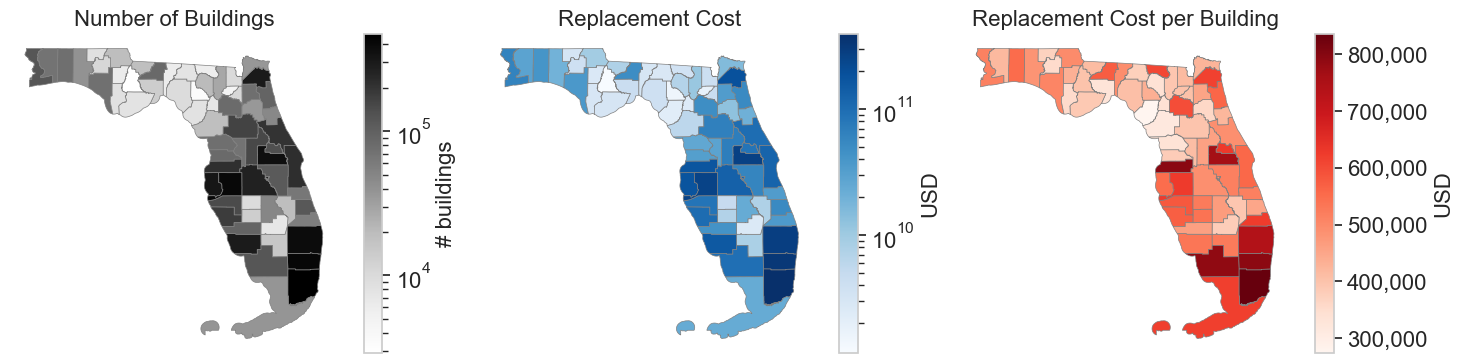

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as mticker


# STEP 1–3: Same as before (assumes merged_all is prepared)
# STEP 1: Filter counties for Florida
florida_counties = counties[counties["STATEFP"] == '12'].copy()
florida_counties["NAME"] = florida_counties["NAME"].str.upper()

# STEP 2: Aggregate metrics
agg_replacement = res_df_ER11.groupby("County")[["ReplacementCost"]].sum().reset_index()
agg_count = res_df_ER11.groupby("County").size().reset_index(name="BuildingCount")

# Clean names
agg_replacement["County"] = agg_replacement["County"].str.upper()
agg_count["County"] = agg_count["County"].str.upper()

# STEP 3: Merge metrics
agg_all = agg_replacement.merge(agg_count, on="County", how="outer")
agg_all["CostPerBuilding"] = agg_all["ReplacementCost"] / agg_all["BuildingCount"]

county_renames = {
    "ST LUCIE": "ST. LUCIE",
    "ST JOHNS": "ST. JOHNS"
}
agg_all["County"] = agg_all["County"].replace(county_renames)

# Merge with spatial geometries
merged_all = florida_counties.merge(agg_all, left_on="NAME", right_on="County", how="left")

# STEP 4: Create 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ("BuildingCount", "Greys", "Number of Buildings"),
    ("ReplacementCost", "Blues", "Replacement Cost"),
    ("CostPerBuilding", "Reds", "Replacement Cost per Building")
]

for idx, (ax, (column, cmap, label)) in enumerate(zip(axes, metrics)):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)

    # Use log scale only for first two
    if column in ["BuildingCount", "ReplacementCost"]:
        data = merged_all[column]
        data_valid = data[data > 0]
        norm = LogNorm(vmin=data_valid.min(), vmax=data_valid.max()) if not data_valid.empty else None
    else:
        norm = None

    # Plot
    merged_all.plot(
        column=column,
        cmap=cmap,
        norm=norm,
        linewidth=0.5,
        edgecolor="0.5",
        legend=True,
        ax=ax,
        cax=cax,
        legend_kwds={'label': label},
        missing_kwds={
            "color": "lightgrey",
            "label": "No data",
            "edgecolor": "white"
        }
    )

    # Axis and title
    ax.set_title(label, fontsize=16)
    ax.axis("off")

    # Format colorbar ticks with commas if rightmost column
    if idx == 2:
        cax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Set colorbar label and tick font size
    cax.set_ylabel(
        "# buildings" if idx == 0 else "USD",
        fontsize=16
    )
    cax.tick_params(labelsize=16)

plt.tight_layout()
plt.savefig("../plots/fl_exposure_overview_logscale.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
agg_all.CostPerBuilding.describe()

count        67.000000
mean     492425.063046
std      127550.427745
min      274248.684067
25%      398844.629654
50%      469285.025795
75%      559222.585006
max      835261.992854
Name: CostPerBuilding, dtype: float64

## Plot: Impact valules per county

In [14]:
res_df_ER11

,id,PlanArea,NumberOfStories,MedianYearBuilt,ReplacementCost,StructureType,NumberOfUnits,CensusBlock,CensusTract,FootprintID,...,DS_2018280N18273,LossRatio_2022266N12294,RepairCost_2022266N12294,DS_2022266N12294,LossRatio_2022311N21293,RepairCost_2022311N21293,DS_2022311N21293,LossRatio_2023239N21274,RepairCost_2023239N21274,DS_2023239N21274
0,0,1853.000000,1.0,1976.0,2.510259e+05,S3,1.0,121150026011001,12115002601,0,...,DS0: None,0.145868,36616.695007,DS3: Extensive,0.000000,0.000000,DS0: None,0.0,0.0,DS0: None
1,1,2242.000000,1.0,1976.0,3.942782e+05,URM,1.0,121150026011014,12115002601,27,...,DS0: None,0.150604,59379.759155,DS3: Extensive,0.000000,0.000000,DS0: None,0.0,0.0,DS0: None
2,2,1472.000000,1.0,1976.0,3.719494e+05,URM,2.0,121150026011014,12115002601,28,...,DS0: None,0.150604,56016.965882,DS3: Extensive,0.000000,0.000000,DS0: None,0.0,0.0,DS0: None
3,3,1125.000000,2.0,1976.0,1.322330e+06,URM,2.0,121150026011014,12115002601,29,...,DS0: None,0.150604,199147.795959,DS3: Extensive,0.000000,0.000000,DS0: None,0.0,0.0,DS0: None
4,4,1272.666667,3.0,1976.0,7.410181e+05,URM,2.0,121150026011014,12115002601,30,...,DS0: None,0.150604,111600.079063,DS3: Extensive,0.000000,0.000000,DS0: None,0.0,0.0,DS0: None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6645941,2890,771.500000,2.0,1984.0,8.124977e+04,MH,1.0,120779502001002,12077950200,4855,...,DS4: Complete,0.000000,0.000000,DS0: None,0.001057,85.873920,DS0: None,0.0,0.0,DS0: None
6645942,2891,780.000000,1.0,1984.0,1.356591e+05,URM,1.0,120779502001000,12077950200,4857,...,DS3: Extensive,0.000000,0.000000,DS0: None,0.000000,0.000000,DS0: None,0.0,0.0,DS0: None
6645943,2892,1312.000000,1.0,1984.0,4.744301e+05,S5,1.0,120779502001002,12077950200,4858,...,DS0: None,0.000000,0.000000,DS0: None,0.000000,0.000000,DS0: None,0.0,0.0,DS0: None
6645944,2893,1796.000000,1.0,1984.0,1.848432e+05,W1,1.0,120779502001002,12077950200,4861,...,DS3: Extensive,0.000000,0.000000,DS0: None,0.000000,0.000000,DS0: None,0.0,0.0,DS0: None


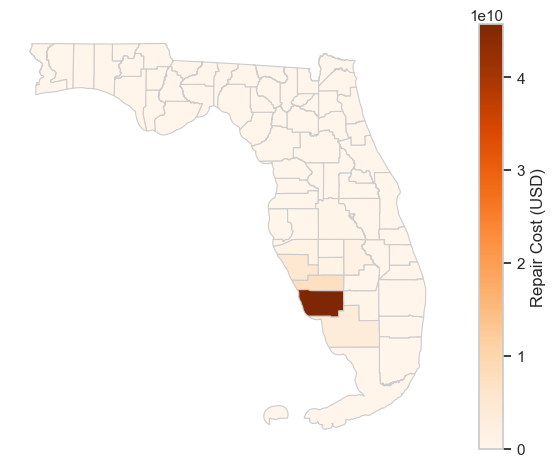

In [15]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# STEP 1: Filter counties for Florida only (assuming STATEFP = '12')
florida_counties = counties[counties["STATEFP"] == '12'].copy()

# STEP 2: Aggregate exposure data by county
agg_exposure = res_df_ER11.groupby("County")[["RepairCost_2022266N12294"]].sum().reset_index()

# Clean up names for merge
agg_exposure["County"] = agg_exposure["County"].str.upper()
florida_counties["NAME"] = florida_counties["NAME"].str.upper()

agg_exposure["County"] = agg_exposure["County"].replace(county_renames)

# STEP 3: Merge exposure data into county geometries
merged = florida_counties.merge(agg_exposure, left_on="NAME", right_on="County", how="left")

# STEP 4: Plot choropleth map
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Create a divider for the axis
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)  # Shrink + pad colorbar

# Plot with custom colorbar axis
merged.plot(
    column="RepairCost_2022266N12294",
    cmap="Oranges",
    linewidth=0.8,
    edgecolor="0.8",
    legend=True,
    ax=ax,
    cax=cax,  # Use custom colorbar axis
    legend_kwds={'label': 'Repair Cost (USD)'},
    missing_kwds={
        "color": "lightgrey",
        "label": "No data",
        "edgecolor": "white"
    }
)

ax.axis("off")
plt.tight_layout()
plt.show()

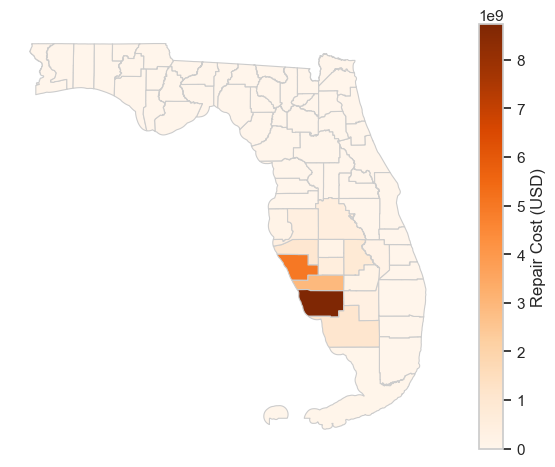

In [16]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# STEP 1: Filter counties for Florida only (assuming STATEFP = '12')
florida_counties = counties[counties["STATEFP"] == '12'].copy()

# STEP 2: Aggregate exposure data by county
agg_exposure = res_df_reask.groupby("County")[["RepairCost_2022266N12294"]].sum().reset_index()

# Clean up names for merge
agg_exposure["County"] = agg_exposure["County"].str.upper()
florida_counties["NAME"] = florida_counties["NAME"].str.upper()

agg_exposure["County"] = agg_exposure["County"].replace(county_renames)

# STEP 3: Merge exposure data into county geometries
merged = florida_counties.merge(agg_exposure, left_on="NAME", right_on="County", how="left")

# STEP 4: Plot choropleth map
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Create a divider for the axis
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)  # Shrink + pad colorbar

# Plot with custom colorbar axis
merged.plot(
    column="RepairCost_2022266N12294",
    cmap="Oranges",
    linewidth=0.8,
    edgecolor="0.8",
    legend=True,
    ax=ax,
    cax=cax,  # Use custom colorbar axis
    legend_kwds={'label': 'Repair Cost (USD)'},
    missing_kwds={
        "color": "lightgrey",
        "label": "No data",
        "edgecolor": "white"
    }
)

ax.axis("off")
plt.tight_layout()
plt.show()

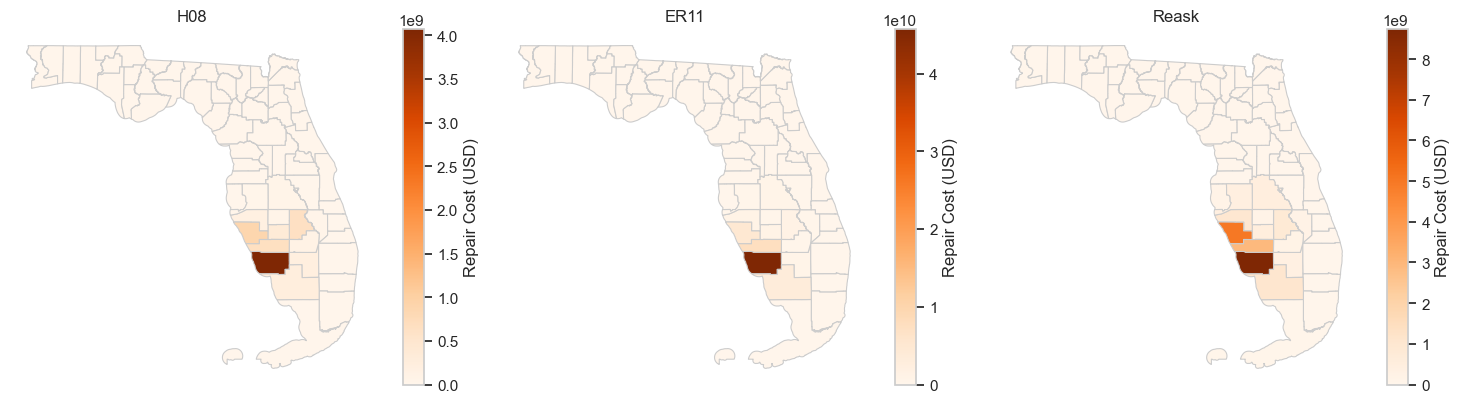

In [17]:
 import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Replace these with your actual DataFrames
res_dfs = [res_df_H08, res_df_ER11, res_df_reask]
event_id = "2022266N12294"
column_name = f"RepairCost_{event_id}"

# Clean up Florida counties for merging
florida_counties = counties[counties["STATEFP"] == '12'].copy()
florida_counties["NAME"] = florida_counties["NAME"].str.upper()

# Prepare figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # Wider figure
titles = ["H08", "ER11", "Reask"]  # Optional subplot titles

for ax, res_df, title in zip(axes, res_dfs, titles):
    # STEP 1: Aggregate exposure data
    agg_exposure = res_df.groupby("County")[[column_name]].sum().reset_index()
    agg_exposure["County"] = agg_exposure["County"].str.upper()
    agg_exposure["County"] = agg_exposure["County"].replace(county_renames)

    # STEP 2: Merge with geometry
    merged = florida_counties.merge(agg_exposure, left_on="NAME", right_on="County", how="left")

    # STEP 3: Setup colorbar axis
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)

    # STEP 4: Plot
    merged.plot(
        column=column_name,
        cmap="Oranges",
        linewidth=0.8,
        edgecolor="0.8",
        legend=True,
        ax=ax,
        cax=cax,
        legend_kwds={'label': 'Repair Cost (USD)'},
        missing_kwds={
            "color": "lightgrey",
            "label": "No data",
            "edgecolor": "white"
        }
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


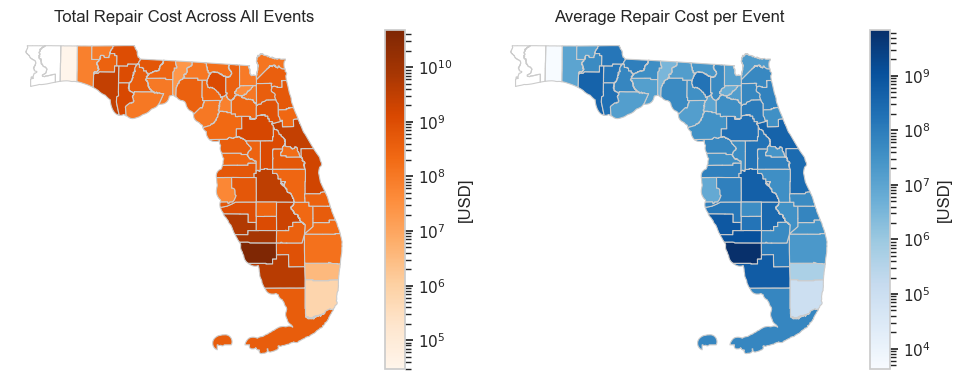

In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter, LogLocator

import numpy as np

log_formatter = FuncFormatter(lambda x, _: f'$10^{{{int(np.log10(x))}}}$' if x > 0 else '')

# Define event IDs
storm_ids = [
    '2016242N24279', '2016273N13300', '2017242N16333',
    '2018280N18273', '2022266N12294', '2022311N21293', '2023239N21274'
]

# Prepare Florida county geometries
florida_counties = counties[counties["STATEFP"] == '12'].copy()
florida_counties["NAME"] = florida_counties["NAME"].str.upper()

# Prepare and aggregate repair costs
repair_cost_cols = [f"RepairCost_{eid}" for eid in storm_ids]
repair_cost_df = res_df_ER11[["County"] + repair_cost_cols].copy()
repair_cost_df[repair_cost_cols] = repair_cost_df[repair_cost_cols].fillna(0)

repair_cost_df["County"] = repair_cost_df["County"].str.upper().replace(county_renames)
repair_cost_df["TotalRepairCost"] = repair_cost_df[repair_cost_cols].sum(axis=1)
repair_cost_df["AvgRepairCost"] = repair_cost_df[repair_cost_cols].mean(axis=1)

agg_costs = repair_cost_df.groupby("County")[["TotalRepairCost", "AvgRepairCost"]].sum().reset_index()
merged = florida_counties.merge(agg_costs, left_on="NAME", right_on="County", how="left")

# Apply log-transform safely (avoid log(0) by replacing 0 with small number)
merged["LogTotal"] = np.log10(merged["TotalRepairCost"].replace(0, np.nanmin(merged["TotalRepairCost"][merged["TotalRepairCost"] > 0]) / 10))
merged["LogAvg"] = np.log10(merged["AvgRepairCost"].replace(0, np.nanmin(merged["AvgRepairCost"][merged["AvgRepairCost"] > 0]) / 10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Total Repair Cost
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="5%", pad=0.05)

vmin_total = merged["TotalRepairCost"].replace(0, np.nan).min()
vmax_total = merged["TotalRepairCost"].max()

norm_total = mcolors.LogNorm(vmin=max(vmin_total, 1), vmax=vmax_total)
img1 = merged.plot(
    column="TotalRepairCost",
    cmap="Oranges",
    norm=norm_total,
    linewidth=0.8,
    edgecolor="0.8",
    ax=ax1,
    legend=False,  # disable auto legend
    missing_kwds={
        "color": "lightgrey",
        "label": "No data",
        "edgecolor": "white"
    }
)
ax1.set_title("Total Repair Cost Across All Events")
ax1.axis("off")

# Manually add colorbar
sm1 = plt.cm.ScalarMappable(norm=norm_total, cmap="Oranges")
cb1 = plt.colorbar(sm1, cax=cax1, format=log_formatter)
#cb1.set_ticks(LogLocator(base=10.0, subs=[1.0], numticks=10))
cb1.set_label("[USD]")

# Average Repair Cost
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="5%", pad=0.05)

vmin_avg = merged["AvgRepairCost"].replace(0, np.nan).min()
vmax_avg = merged["AvgRepairCost"].max()

norm_avg = mcolors.LogNorm(vmin=max(vmin_avg, 1), vmax=vmax_avg)
img2 = merged.plot(
    column="AvgRepairCost",
    cmap="Blues",
    norm=norm_avg,
    linewidth=0.8,
    edgecolor="0.8",
    ax=ax2,
    legend=False,  # disable auto legend
    missing_kwds={
        "color": "lightgrey",
        "label": "No data",
        "edgecolor": "white"
    }
)
ax2.set_title("Average Repair Cost per Event")
ax2.axis("off")

# Manually add colorbar
sm2 = plt.cm.ScalarMappable(norm=norm_avg, cmap="Blues")
cb2 = plt.colorbar(sm2, cax=cax2, format=log_formatter)
#cb2.set_ticks(LogLocator(base=10.0, subs=[1.0], numticks=10))
cb2.set_label("[USD]")

plt.tight_layout()
plt.show()


In [19]:
res_df_ER11.columns

Index(['id', 'PlanArea', 'NumberOfStories', 'MedianYearBuilt',
       'ReplacementCost', 'StructureType', 'NumberOfUnits', 'CensusBlock',
       'CensusTract', 'FootprintID', 'OccupancyClass', 'footprint_geometry',
       'County', 'value', 'geometry', 'impf_TC', 'centr_TC',
       'LossRatio_2016242N24279', 'RepairCost_2016242N24279',
       'DS_2016242N24279', 'LossRatio_2016273N13300',
       'RepairCost_2016273N13300', 'DS_2016273N13300',
       'LossRatio_2017242N16333', 'RepairCost_2017242N16333',
       'DS_2017242N16333', 'LossRatio_2018280N18273',
       'RepairCost_2018280N18273', 'DS_2018280N18273',
       'LossRatio_2022266N12294', 'RepairCost_2022266N12294',
       'DS_2022266N12294', 'LossRatio_2022311N21293',
       'RepairCost_2022311N21293', 'DS_2022311N21293',
       'LossRatio_2023239N21274', 'RepairCost_2023239N21274',
       'DS_2023239N21274'],
      dtype='object')

In [20]:
res_df_ER11.footprint_geometry

0          POLYGON ((-82.44246760000001 27.05639839999999...
1          POLYGON ((-82.3757927 26.9523084, -82.3758647 ...
2          POLYGON ((-82.37579740000001 26.95278239999999...
3          POLYGON ((-82.3761387 26.953549899999995, -82....
4          POLYGON ((-82.376456 26.953530699999998, -82.3...
                                 ...                        
6645941    POLYGON ((-84.90162926869847 30.59673107486944...
6645942    POLYGON ((-84.8931742639667 30.59599749895286,...
6645943    POLYGON ((-84.90210569994042 30.59752612438604...
6645944    POLYGON ((-84.90100528954483 30.5971765758621,...
6645945    POLYGON ((-84.90074601443469 30.59745352733526...
Name: footprint_geometry, Length: 6645946, dtype: object

In [23]:
res_df.FootprintID

0             0
1            27
2            28
3            29
4            30
           ... 
6645941    4855
6645942    4857
6645943    4858
6645944    4861
6645945    4862
Name: FootprintID, Length: 6645946, dtype: int64

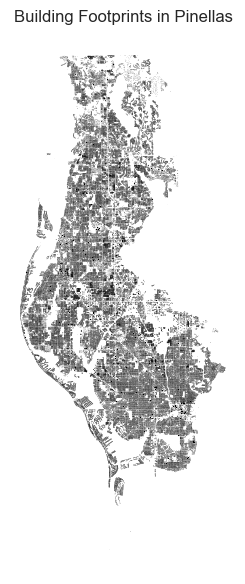

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt

# STEP 1: Filter to Pinellas County
pinellas_df = res_df_ER11[res_df_ER11["County"].str.upper() == "PINELLAS"].copy()

# STEP 2: Convert WKT strings to shapely geometries
pinellas_df["geometry"] = pinellas_df["footprint_geometry"].apply(wkt.loads)

# STEP 3: Create GeoDataFrame
gdf_footprints = gpd.GeoDataFrame(pinellas_df, geometry="geometry", crs="EPSG:4326")

# STEP 4 (Optional): Filter out invalid or null geometries
gdf_footprints = gdf_footprints[gdf_footprints.geometry.notnull() & gdf_footprints.is_valid]

# STEP 5: Plot
fig, ax = plt.subplots(figsize=(6, 6))
gdf_footprints.plot(ax=ax, linewidth=0.05, edgecolor='black', facecolor='black')
ax.set_title("Building Footprints in Pinellas")
ax.axis("off")
plt.tight_layout()
#plt.savefig("../plots/buildings_map_pinellas.png", dpi=300, bbox_inches="tight")
plt.show()

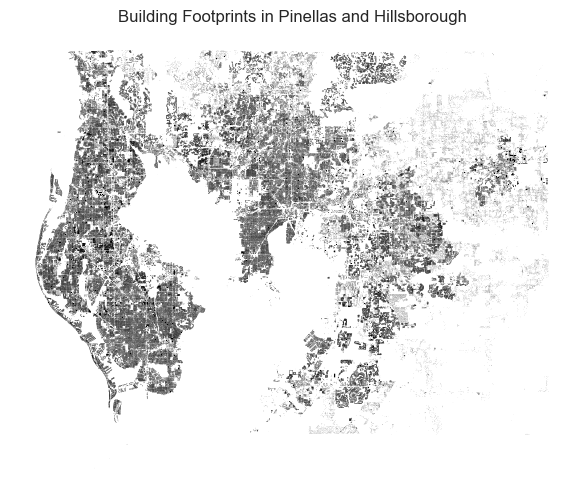

In [74]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt

# STEP 1: Filter for both counties (case-insensitive match)
counties_to_plot = ["PINELLAS", "HILLSBOROUGH"]
df_subset = res_df_ER11[res_df_ER11["County"].str.upper().isin(counties_to_plot)].copy()

# STEP 2: Convert WKT strings to shapely geometries
df_subset["geometry"] = df_subset["footprint_geometry"].apply(wkt.loads)

# STEP 3: Create GeoDataFrame
gdf_footprints = gpd.GeoDataFrame(df_subset, geometry="geometry", crs="EPSG:4326")

# STEP 4: Optional cleanup
gdf_footprints = gdf_footprints[gdf_footprints.geometry.notnull() & gdf_footprints.is_valid]

# STEP 5: Plot
fig, ax = plt.subplots(figsize=(6, 6))
gdf_footprints.plot(ax=ax, linewidth=0.05, edgecolor='black', facecolor='black')

ax.set_title("Building Footprints in Pinellas and Hillsborough")
ax.axis("off")
plt.tight_layout()
#plt.savefig("../plots/buildings_map_pin-hill.png", dpi=300, bbox_inches="tight")
plt.show()


KeyboardInterrupt: 

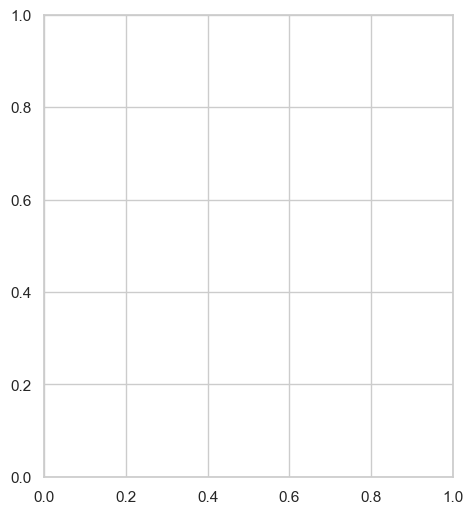

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely import wkt
import numpy as np

# STEP 1: Filter and convert geometry
counties_to_plot = ["PINELLAS", "HILLSBOROUGH"]
#counties_to_plot = ["PINELLAS"]

df_subset = res_df_ER11[res_df_ER11["County"].str.upper().isin(counties_to_plot)].copy()
df_subset["geometry"] = df_subset["footprint_geometry"].apply(wkt.loads)

gdf_footprints = gpd.GeoDataFrame(df_subset, geometry="geometry", crs="EPSG:4326")
gdf_footprints = gdf_footprints[gdf_footprints.geometry.notnull() & gdf_footprints.is_valid]

# STEP 2: Set LogNorm scaling based on full range (min > 0 to avoid log(0))
vmin = gdf_footprints["ReplacementCost"].replace(0, np.nan).min()
vmax = gdf_footprints["ReplacementCost"].max()
norm = mcolors.LogNorm(vmin=max(vmin, 1), vmax=vmax)

# STEP 3: Plot
fig, ax = plt.subplots(figsize=(6, 6))

gdf_footprints.plot(
    ax=ax,
    column="ReplacementCost",
    cmap="inferno",
    norm=norm,
    linewidth=0,          
    edgecolor=None,
    legend=True,
    legend_kwds={
        "label": "Replacement Cost [USD]",
        "shrink": 0.6
    }
)

#ax.set_title("Building Footprints Colored by Replacement Cost (Log Scale, Turbo Colormap)")
ax.axis("off")
plt.tight_layout()
#plt.savefig("../plots/replacement_cost_buildings_map_pinellas.png", dpi=300, bbox_inches="tight")
plt.show()

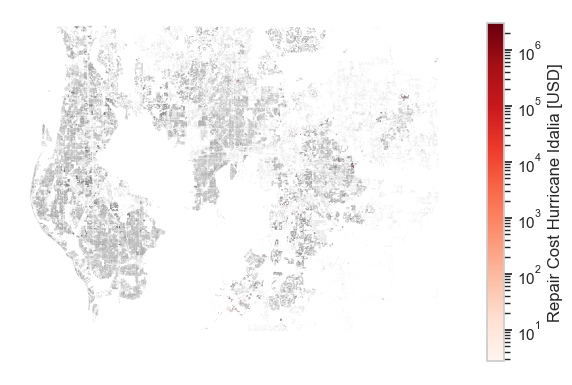

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely import wkt
import numpy as np

event_id = "2017242N16333"

# STEP 1: Filter and convert geometry
counties_to_plot = ["PINELLAS", "HILLSBOROUGH"]
#counties_to_plot = ["PINELLAS"]

df_subset = res_df_ER11[res_df_ER11["County"].str.upper().isin(counties_to_plot)].copy()
df_subset["geometry"] = df_subset["footprint_geometry"].apply(wkt.loads)

gdf_footprints = gpd.GeoDataFrame(df_subset, geometry="geometry", crs="EPSG:4326")
gdf_footprints = gdf_footprints[gdf_footprints.geometry.notnull() & gdf_footprints.is_valid]

# STEP 2: Set LogNorm scaling based on full range (min > 0 to avoid log(0))
vmin = gdf_footprints[f"RepairCost_{event_id}"].replace(0, np.nan).min()
vmax = gdf_footprints[f"RepairCost_{event_id}"].max()
norm = mcolors.LogNorm(vmin=max(vmin, 1), vmax=vmax)

# STEP 3: Plot
fig, ax = plt.subplots(figsize=(6, 6))

gdf_footprints.plot(
    ax=ax,
    column=f"RepairCost_{event_id}",
    cmap="Reds",
    norm=norm,
    linewidth=0.01,          
    edgecolor="k",
    legend=True,
    legend_kwds={
        "label": "Repair Cost Hurricane Idalia [USD]",
        "shrink": 0.6
    }
)

#ax.set_title("Building Footprints Colored by Replacement Cost (Log Scale, Turbo Colormap)")
ax.axis("off")
plt.tight_layout()
#plt.savefig("../plots/repair_cost_idalia_buildings_map_pin-hill.png", dpi=300, bbox_inches="tight")
plt.show()

In [60]:
vmax = gdf_footprints[f"RepairCost_{event_id}"].max()

In [61]:
vmax

2986849.4878169787

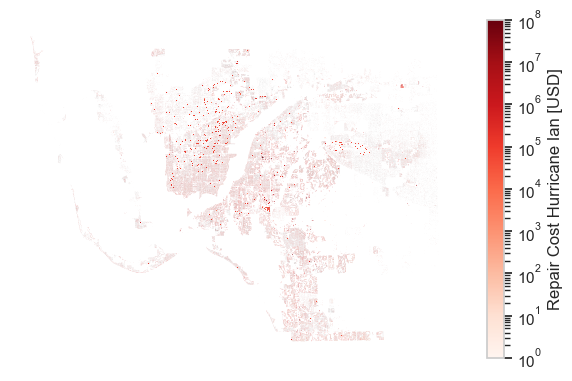

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely import wkt
import numpy as np

event_id = "2022266N12294"

# STEP 1: Filter and convert geometry
counties_to_plot = ["LEE"]

df_subset = res_df_ER11[res_df_reask["County"].str.upper().isin(counties_to_plot)].copy()
df_subset["geometry"] = df_subset["footprint_geometry"].apply(wkt.loads)

gdf_footprints = gpd.GeoDataFrame(df_subset, geometry="geometry", crs="EPSG:4326")
gdf_footprints = gdf_footprints[gdf_footprints.geometry.notnull() & gdf_footprints.is_valid]

# STEP 2: Set LogNorm scaling based on full range (min > 0 to avoid log(0))
vmin = gdf_footprints[f"RepairCost_{event_id}"].replace(0, np.nan).min()
vmax = gdf_footprints[f"RepairCost_{event_id}"].max()
norm = mcolors.LogNorm(vmin=max(vmin, 1), vmax=vmax)

# STEP 3: Plot
fig, ax = plt.subplots(figsize=(6, 6))

gdf_footprints.plot(
    ax=ax,
    column=f"RepairCost_{event_id}",
    cmap="Reds",
    norm=norm,
    linewidth=0.01,          
    edgecolor=None,
    legend=True,
    legend_kwds={
        "label": "Repair Cost Hurricane Ian [USD]",
        "shrink": 0.6
    }
)

#ax.set_title("Building Footprints Colored by Replacement Cost (Log Scale, Turbo Colormap)")
ax.axis("off")
plt.tight_layout()
#plt.savefig("../plots/repair_cost_ian_buildings_map_lee1.png", dpi=300, bbox_inches="tight")
plt.show()

## Load Florida Exposure to Get Total Units per County

In [ ]:
# Load Florida exposure data to get total units per county
import pandas as pd
from pathlib import Path

exposure_file = Path("../data/exposure/states/florida_exposure.hdf5")
fl_exposure = pd.read_hdf(exposure_file)

# Check what columns are available
print("Columns in Florida exposure:")
print(fl_exposure.columns.tolist())
print(f"\nTotal records: {len(fl_exposure):,}")
fl_exposure.head(3)

In [ ]:
# Aggregate total units by county FIPS
# Assuming 'region_id' or similar column contains FIPS codes
# and 'value' or 'n_units' contains the number of units

# First, let's check for FIPS-related columns
fips_cols = [col for col in fl_exposure.columns if 'fips' in col.lower() or 'region' in col.lower() or 'county' in col.lower()]
print("FIPS/County related columns:", fips_cols)

# Check for value columns
value_cols = [col for col in fl_exposure.columns if 'value' in col.lower() or 'unit' in col.lower() or 'number' in col.lower()]
print("Value/Unit related columns:", value_cols)

In [ ]:
# Count total units per county
# Each row represents one building/unit, so we just count rows per FIPS
if 'region_id' in fl_exposure.columns:
    fl_units_per_county = fl_exposure.groupby('region_id').size().reset_index(name='total_units')
    fl_units_per_county.columns = ['fips', 'total_units']
    
    # Ensure FIPS is integer
    fl_units_per_county['fips'] = fl_units_per_county['fips'].astype(int)
    
    print(f"\n✓ Aggregated {len(fl_units_per_county)} Florida counties")
    print(f"  Total units across Florida: {fl_units_per_county['total_units'].sum():,}")
    
    # Show sample
    print("\nSample - units per county:")
    print(fl_units_per_county.sort_values('total_units', ascending=False).head(10))
else:
    print("Warning: 'region_id' column not found. Check exposure structure.")

## Calculate Damage Percentage for Event Counties

In [ ]:
# For the event analysis, merge total units and calculate damage percentage
# Assuming you have event_counties DataFrame from previous analysis

# Example: let's check if event_counties exists from the other notebook
# If not, we'll need to load it here
try:
    # Try to use existing event_counties if available
    if 'event_counties' in locals():
        event_with_total = event_counties.merge(fl_units_per_county, on='fips', how='left')
        event_with_total['damage_pct'] = (event_with_total['total_damage_units'] / event_with_total['total_units']) * 100
        
        print("=== Event Analysis with Total Units ===\n")
        print(f"FIPS     Damage    Total     Damage%   Capacity   Recovery")
        print("-" * 70)
        
        for _, row in event_with_total.sort_values('damage_pct', ascending=False).iterrows():
            print(f"{int(row['fips'])}   {int(row['total_damage_units']):5d}     "
                  f"{int(row['total_units']):6d}    {row['damage_pct']:5.1f}%    "
                  f"{row['construction_capacity']:6.1f}    {row['recovery_months']:6.1f} mo")
    else:
        print("Note: event_counties not found. You'll need to load the event data first.")
        print("This cell shows you HOW to calculate damage percentage once you have the event data.")
        
except Exception as e:
    print(f"Note: {e}")
    print("\nYou can merge total units with any event DataFrame like this:")
    print("  event_with_total = event_df.merge(fl_units_per_county, on='fips', how='left')")
    print("  event_with_total['damage_pct'] = (event_with_total['total_damage_units'] / event_with_total['total_units']) * 100")